# Where is North Atlantic Deep Water formed, and by what process?

North Atlantic Deep Water (NADW) is the dense water mass that fills the deep Atlantic and forms the lower limb of the Atlantic Meridional Overturning Circulation. Textbooks tell us it is "formed by wintertime cooling in the subpolar North Atlantic and Nordic Seas." This notebook asks a sharper question of an actual ocean model:

> **At which densities, in which places, and through which physical process does the model actually convert lighter water into NADW?**

We will answer it with `xwmt`, and the answer turns out to be more interesting than the textbook summary — the surface fluxes that everyone points to do *not*, on their own, make the densest water.

## What you'll learn

- How to define a **geographic region mask** on a curvilinear (tripolar) ocean grid, where the horizontal dimensions are *indices*, not longitude and latitude.
- How to use the per-call `mask=` keyword to compute regional and global transformations from a single `WaterMassTransformations` object.
- Why you should bin on the model's **native density interfaces**, and what the **prebinned** code path inside `xwmt` does (including how `rebin=True` changes the answer).
- How to **decompose** surface forcing into latent, sensible, longwave and shortwave contributions.
- How to locate the peak transformation isopycnal **programmatically** and **map** where it happens.

## Prerequisites

Work through [the quickstart](quickstart.ipynb) first, and ideally [Evaluating water mass transformations from finite-volume tracer budget terms](closed_transformation_budget.ipynb), which introduces `xbudget`, the budget dictionary, and the transformation sign convention that we use throughout without re-deriving.

## Data

**1.08 GB** (shared with `closed_transformation_budget.ipynb`) · downloads once into `data/` and is reused · this notebook runs in **~2 min** once the data are local.

## Caveats — please read these first

It would be dishonest to present the figures below as "the answer" without first being clear about what this particular dataset can and cannot support. Three limitations shape every result in this notebook.

**1. It is a single annual mean.** The file contains exactly one time record: an annual mean for the year 2000. There is no seasonal cycle to composite. This matters more than usual here, because NADW is formed during *wintertime convection* — a few violent weeks in which the mixed layer deepens by hundreds of metres. An annual mean smears that burst across the whole year and mixes it with the restratifying summer. So everything below is **annual-mean formation**, not the winter formation rate, and the two are not the same number.

**2. The grid is coarse.** At a ~1.5° nominal resolution, the Denmark Strait and Faroe Bank Channel overflows — the plumbing that actually delivers the densest NADW into the deep Atlantic — are only a few cells wide, and the model represents them with heavily parameterised mixing. Read what follows as **basin-scale** NADW formation, not as overflow dynamics.

**3. The regional budget does not close.** We integrate over a North Atlantic box, and water flows in and out through the sides of that box. Those lateral transports are a genuine term in the regional water mass budget, and `xwmt` does not compute them: `xwmt` gives you the transformation terms, not the convergence of transport across a region's perimeter. Closing a regional budget is the job of the companion package [xwmb](https://github.com/hdrake/xwmb) (water mass budgets), which builds on `xwmt` and handles exactly this. If you want the full budget rather than the transformation terms, that is where to go next.

With those stated, let's proceed.

## Setup

In [1]:
import os
import warnings

import numpy as np
import matplotlib.pyplot as plt
from dask.diagnostics import ProgressBar

import xwmt
import xbudget

from load_example_model_grid import load_MOM6_coarsened_diagnostics

# Warnings are rendered with only the base name of the file that raised them. The
# default format uses the absolute path, which would bake whoever-ran-this's home
# directory into the committed output and the published documentation -- while
# still showing whether a warning came from a library or from this notebook.
warnings.formatwarning = (
    lambda msg, cat, filename, lineno, *_:
    f"{os.path.basename(filename)}:{lineno}: {cat.__name__}: {msg}\n"
)


Loading the data and building the `xgcm.Grid` object is handled by the same helper used in the other MOM6 examples. As a reminder, the grid object carries the full diagnostic dataset on its `_ds` attribute.

In [2]:
grid = load_MOM6_coarsened_diagnostics()
ds = grid._ds
ds

File 'MOM6_global_example_sigma2_budgets_v0_0_6.nc' already exists at data/MOM6_global_example_sigma2_budgets_v0_0_6.nc. Skipping download.


<xarray.Dataset> Size: 1GB
Dimensions:                         (time_bounds: 2, sigma2_l: 74, yh: 180,
                                     xh: 240, time: 1, xq: 241, yq: 181,
                                     sigma2_i: 75)
Coordinates: (12/28)
  * time_bounds                     (time_bounds) object 16B 2000-01-01 00:00...
    time_bounds_since_init          (time_bounds) object 16B dask.array<chunksize=(2,), meta=np.ndarray>
  * sigma2_l                        (sigma2_l) float64 592B 4.246 ... 38.49
    rho2_l                          (sigma2_l) float64 592B dask.array<chunksize=(74,), meta=np.ndarray>
  * yh                              (yh) int64 1kB 0 1 2 3 4 ... 176 177 178 179
  * xh                              (xh) int64 2kB 0 1 2 3 4 ... 236 237 238 239
    ...                              ...
    geolon_c                        (yq, xq) float64 349kB dask.array<chunksize=(181, 241), meta=np.ndarray>
    geolon_u                        (yh, xq) float64 347kB dask.array<chunksize=(180, 241), meta=np.ndarray>
    wet_u                           (yh, xq) float32 174kB dask.array<chunksize=(180, 241), meta=np.ndarray>
  * yq                              (yq) int64 1kB 0 1 2 3 4 ... 177 178 179 180
  * sigma2_i                        (sigma2_i) float64 600B -3.0 11.49 ... 39.0
    rho2_i                          (sigma2_i) float64 600B dask.array<chunksize=(75,), meta=np.ndarray>
Data variables: (12/46)
    sigma2_bounds                   (time_bounds, sigma2_l, yh, xh) float64 51MB dask.array<chunksize=(2, 74, 180, 240), meta=np.ndarray>
    so_bounds                       (time_bounds, sigma2_l, yh, xh) float32 26MB dask.array<chunksize=(2, 74, 180, 240), meta=np.ndarray>
    thetao_bounds                   (time_bounds, sigma2_l, yh, xh) float32 26MB dask.array<chunksize=(2, 74, 180, 240), meta=np.ndarray>
    thkcello_bounds                 (time_bounds, sigma2_l, yh, xh) float32 26MB dask.array<chunksize=(2, 74, 180, 240), meta=np.ndarray>
    S_advection_xy                  (time, sigma2_l, yh, xh) float64 26MB dask.array<chunksize=(1, 74, 180, 240), meta=np.ndarray>
    Sh_tendency_vert_remap          (time, sigma2_l, yh, xh) float64 26MB dask.array<chunksize=(1, 74, 180, 240), meta=np.ndarray>
    ...                              ...
    umo                             (time, sigma2_l, yh, xq) float64 26MB dask.array<chunksize=(1, 74, 180, 241), meta=np.ndarray>
    vert_remap_h_tendency           (time, sigma2_l, yh, xh) float64 26MB dask.array<chunksize=(1, 74, 180, 240), meta=np.ndarray>
    vmo                             (time, sigma2_l, yq, xh) float64 26MB dask.array<chunksize=(1, 74, 181, 240), meta=np.ndarray>
    vprec                           (time, sigma2_l, yh, xh) float64 26MB dask.array<chunksize=(1, 74, 180, 240), meta=np.ndarray>
    wfo                             (time, sigma2_l, yh, xh) float64 26MB dask.array<chunksize=(1, 74, 180, 240), meta=np.ndarray>
    zos                             (time, yh, xh) float64 346kB dask.array<chunksize=(1, 180, 240), meta=np.ndarray>
Attributes:
    description:  An example netcdf file containing all variables required to...
    version:      0_0_6
    doi:          10.5281/zenodo.15384910

The vertical coordinate is worth noticing immediately: this model's `Z` axis **is** potential density referenced to 2000 dbar, $\sigma_{2}$, with layer centers `sigma2_l` and interfaces `sigma2_i`. That fact drives several decisions later in this notebook.

Next we load the preset MOM6 budget dictionary and aggregate it down to its top-level process terms, exactly as in [the closed budget example](closed_transformation_budget.ipynb).

In [3]:
budgets_dict = xbudget.load_preset_budget(model="MOM6")
xbudget.collect_budgets(grid, budgets_dict)
simple_budgets = xbudget.BudgetQuery(grid, budgets_dict).aggregate()

# Unit conversion: xwmt returns transformation rates as a mass flux in kg/s.
# Dividing by a reference density and scaling to 10^6 m^3/s gives Sverdrups,
# the customary unit for ocean volume transports.
rho_ref = 1035.0
Sv = 1e-6 / rho_ref

## 1. Defining the North Atlantic on a tripolar grid

Here is the first practical obstacle, and it catches almost everyone the first time.

MOM6 runs on a **tripolar** grid: south of about 65°N it is a regular latitude-longitude mesh, but to avoid a singularity at the North Pole the grid's northern cap is stitched together from two poles placed over land. The consequence for us is that `xh` and `yh` — the dimensions of every field in the dataset — are **integer indices, not longitude and latitude**. Writing `ds.sel(yh=slice(45, 80))` would silently give you rows 45 through 80 of the array, somewhere in the far Southern Ocean, and would not raise an error.

Geography instead lives in the **two-dimensional** coordinate variables `geolon` and `geolat`, which give the true longitude and latitude of every cell center. There is also no `basin` variable in this file, so a mask has to be built by hand.

In [4]:
print(f"xh is {ds.xh.dtype}, ranging {float(ds.xh.min()):.1f} .. {float(ds.xh.max()):.1f}"
      "  <- these are indices, not longitudes!")
print(f"yh is {ds.yh.dtype}, ranging {float(ds.yh.min()):.1f} .. {float(ds.yh.max()):.1f}")
print()
print(f"geolon has dims {ds.geolon.dims} and ranges "
      f"{float(ds.geolon.min()):.2f} .. {float(ds.geolon.max()):.2f}")
print(f"geolat has dims {ds.geolat.dims} and ranges "
      f"{float(ds.geolat.min()):.2f} .. {float(ds.geolat.max()):.2f}")

xh is int64, ranging 0.0 .. 239.0  <- these are indices, not longitudes!
yh is int64, ranging 0.0 .. 179.0

geolon has dims ('yh', 'xh') and ranges -299.98 .. 59.98
geolat has dims ('yh', 'xh') and ranges -81.31 .. 89.63


Look carefully at that longitude range: **-299.98 to 59.98**. This is neither the -180..180 convention nor the 0..360 convention — it is a 360°-wide window whose seam happens to sit near 60°E. If you assume a convention rather than checking, you will build the wrong mask.

The fix is a standard normalization into -180..180:

In [5]:
lon = ((ds.geolon + 180) % 360) - 180
print(f"normalized longitude ranges {float(lon.min()):.2f} .. {float(lon.max()):.2f}")

normalized longitude ranges -179.88 .. 179.98


It is worth being precise about *when* this matters, rather than treating it as a ritual. For the North Atlantic box we are about to build, the raw and normalized longitudes happen to agree exactly — every cell in 80°W–20°E has a raw `geolon` in -80..20 as well, so a reader who never normalized would get lucky and never find out. Cross the dateline, however, and the two conventions diverge completely:

In [6]:
na_raw  = (ds.geolon > -80) & (ds.geolon < 20) & (ds.geolat > 45) & (ds.geolat < 80) & (ds.wet > 0)
na_norm = (lon > -80) & (lon < 20) & (ds.geolat > 45) & (ds.geolat < 80) & (ds.wet > 0)
print(f"North Atlantic box   -- raw: {int(na_raw.sum())} cells, normalized: {int(na_norm.sum())} cells "
      f"(identical: {bool((na_raw == na_norm).all())})")

# The same box written across the dateline tells a very different story.
dateline_raw  = ((ds.geolon > 170) & (ds.geolon < 190) & (ds.wet > 0))
dateline_norm = (((lon > 170) | (lon < -170)) & (ds.wet > 0))
print(f"Dateline box (+/-10) -- raw: {int(dateline_raw.sum())} cells, "
      f"normalized: {int(dateline_norm.sum())} cells")

North Atlantic box   -- raw: 2160 cells, normalized: 2160 cells (identical: True)
Dateline box (+/-10) -- raw: 0 cells, normalized: 2203 cells


The raw-longitude dateline mask selects **zero cells** and would have quietly produced a budget of exactly zero everywhere, with no warning of any kind. Normalize, and check the range of what you normalized.

### The region

We take a box spanning **80°W–20°E, 45°N–80°N**. The eastern boundary at 20°E is deliberate: a box that stopped further west would clip the **Nordic Seas**, where much of the densest water in the region is formed before spilling south over the Greenland–Scotland Ridge. Our box therefore covers the Labrador Sea, the Irminger Sea, the Iceland Basin and the Nordic Seas together. In Section 6 we will separate the Nordic Seas from the rest of the box and show, quantitatively, just how much that choice mattered.

In [7]:
mask = (lon > -80) & (lon < 20) & (ds.geolat > 45) & (ds.geolat < 80) & (ds.wet > 0)
print(f"North Atlantic mask selects {int(mask.sum())} of {mask.size} grid cells "
      f"({100*float(mask.sum())/mask.size:.1f}%)")

North Atlantic mask selects 2160 of 43200 grid cells (5.0%)


Note the `ds.wet > 0` test, and not `ds.wet == 1`. In this coarsened dataset `wet` is a **fractional** land-sea mask: coarsening a fine grid onto a 1.5° mesh leaves many cells that are part ocean and part land, and their `wet` values lie strictly between 0 and 1. Those partially-wet cells are precisely the coastal and marginal-sea cells that matter most in the subpolar North Atlantic, so testing `wet == 1` would throw away a great deal of the region we care about.

In [8]:
n_partial = int(((ds.wet > 0) & (ds.wet < 1)).sum())
n_partial_box = int((mask & (ds.wet < 1)).sum())
print(f"{n_partial} cells globally are strictly between 0 and 1 -> `wet` is fractional, not boolean.")
print(f"Cells lost inside our box if you (wrongly) wrote `wet == 1`: {n_partial_box} "
      f"of {int(mask.sum())} ({100*n_partial_box/int(mask.sum()):.0f}%)")

3824 cells globally are strictly between 0 and 1 -> `wet` is fractional, not boolean.
Cells lost inside our box if you (wrongly) wrote `wet == 1`: 519 of 2160 (24%)


Let's look at the region. Because `geolon` and `geolat` are two-dimensional, `xarray`'s `pcolormesh` will happily draw the curvilinear mesh in true geographic coordinates if we pass them as `x` and `y` — no map-projection library required. (This notebook deliberately avoids `cartopy`, which is not an `xwmt` dependency.) Following the convention of the closed-budget example, the coastline is drawn as the zero contour of `wet`.

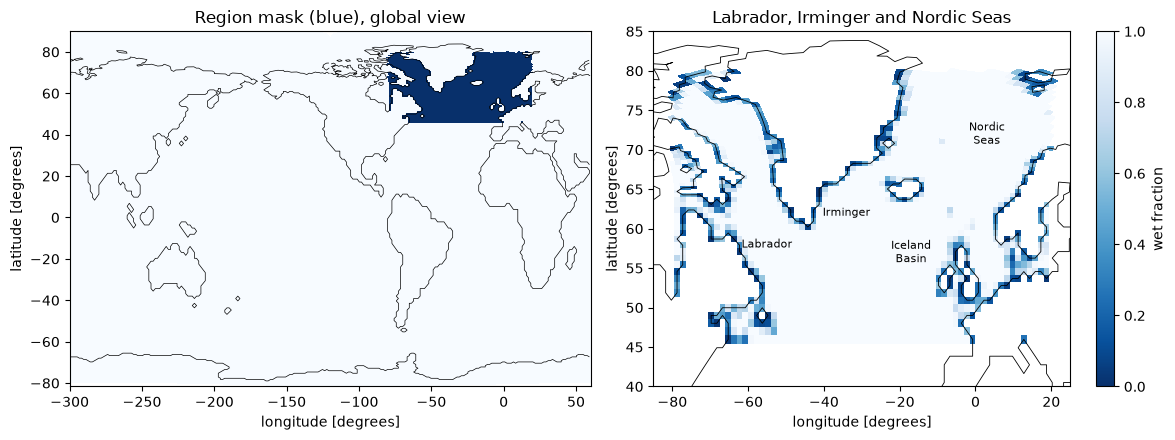

In [9]:
plt.figure(figsize=(12, 4.5))

plt.subplot(1, 2, 1)
mask.plot(x="geolon", y="geolat", cmap="Blues", add_colorbar=False)
(ds.wet == 0).plot.contour(levels=[0], colors="k", x="geolon", y="geolat", linewidths=0.5)
plt.xlabel("longitude [degrees]")
plt.ylabel("latitude [degrees]")
plt.title("Region mask (blue), global view")

plt.subplot(1, 2, 2)
ds.wet.where(mask).plot(x="geolon", y="geolat", cmap="Blues_r", vmin=0, vmax=1,
                        cbar_kwargs={"label": "wet fraction"})
(ds.wet == 0).plot.contour(levels=[0], colors="k", x="geolon", y="geolat", linewidths=0.6)
plt.xlim(-85, 25)
plt.ylim(40, 85)
plt.xlabel("longitude [degrees]")
plt.ylabel("latitude [degrees]")
plt.title("Labrador, Irminger and Nordic Seas")
for name, (x0, y0) in {
    "Labrador": (-55, 58), "Irminger": (-34, 62), "Iceland\nBasin": (-17, 57), "Nordic\nSeas": (3, 72),
}.items():
    plt.text(x0, y0, name, fontsize=8, ha="center", va="center")
plt.tight_layout()

The fractional coastal cells are visible as the paler fringe around Greenland, Iceland and the Canadian Arctic — exactly the cells that a `wet == 1` test would have discarded.

## 2. Choosing density bins: use the model's own interfaces

A tempting default is `bins=np.arange(28, 38, 0.2)`, and other examples in this documentation do exactly that. Here we will use `ds.sigma2_i.values` — the model's **native** density interfaces — instead, for two reasons.

First, this model's vertical coordinate *is* $\sigma_{2}$. The data are therefore **already binned in density** before `xwmt` ever sees them. Asking for target bins finer than the native layer spacing cannot recover information that the discretization never carried; it merely interpolates, and can introduce artifacts.

Second, the native coordinate is not uniform. It has been deliberately refined precisely across the density range that NADW occupies:

75 native interfaces spanning -3.0 .. 39.0
layer thickness ranges 0.016 .. 14.492 kg/m^3 -- a factor of 906
26 of them (35%) fall in the narrow NADW band 36.4-37.3,
which is only 2% of the coordinate's total range.


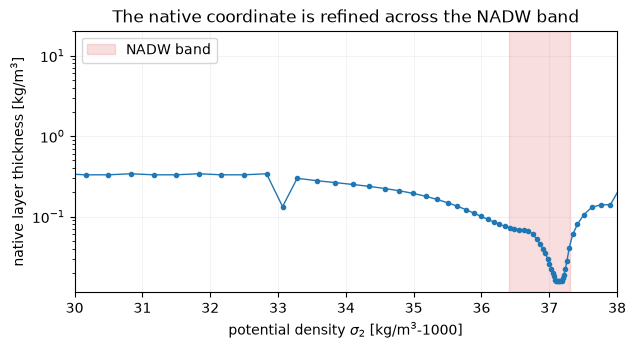

In [10]:
sigma2_i = ds.sigma2_i.values
d = np.diff(sigma2_i)
nadw_band = (sigma2_i >= 36.4) & (sigma2_i <= 37.3)

print(f"{len(sigma2_i)} native interfaces spanning {sigma2_i.min():.1f} .. {sigma2_i.max():.1f}")
print(f"layer thickness ranges {d.min():.3f} .. {d.max():.3f} kg/m^3 -- a factor of {d.max()/d.min():.0f}")
print(f"{int(nadw_band.sum())} of them ({100*nadw_band.sum()/len(sigma2_i):.0f}%) fall in the narrow "
      f"NADW band 36.4-37.3,")
print(f"which is only {100*0.9/(sigma2_i.max()-sigma2_i.min()):.0f}% of the coordinate's total range.")

plt.figure(figsize=(7, 3.4))
plt.plot(0.5*(sigma2_i[1:] + sigma2_i[:-1]), d, ".-", lw=1)
plt.axvspan(36.4, 37.3, color="C3", alpha=0.15, label="NADW band")
plt.yscale("log")
plt.xlim(30, 38)
plt.xlabel(r"potential density $\sigma_{2}$ [kg/m$^{3}$-1000]")
plt.ylabel(r"native layer thickness [kg/m$^{3}$]")
plt.title("The native coordinate is refined across the NADW band")
plt.legend()
plt.grid(True, alpha=0.15)

A third of the model's density levels are packed into the NADW band, where layers are as thin as 0.016 kg/m³ — an order of magnitude finer than a `np.arange(..., 0.2)` grid. Using the native interfaces is both more faithful *and* better resolved than the obvious default.

### The prebinned code path

This deserves an explicit note, because `xwmt` behaves differently here than the documentation elsewhere might lead you to expect.

When the requested $\lambda$ coordinate is already a coordinate of the `xgcm.Grid`'s `Z` axis — as $\sigma_{2}$ is here, with both `sigma2_l` and `sigma2_i` present — `xwmt` detects this and takes its **prebinned** branch. Two consequences follow:

1. It uses the model's own `sigma2_l` as the density field, rather than recomputing density from temperature and salinity through an equation of state.
2. It performs the transformation with `xgcm`, regardless of what you passed as `method=`. The `method` keyword is effectively ignored on this path. Reassuringly, `xwmt` resolves this per call and does *not* mutate the object's `method` attribute, so a later call with a non-prebinned $\lambda$ still behaves as you asked.

Every MOM6 density calculation in this documentation relies on this branch, so it is worth knowing that it exists. We check for it the same way `xwmt` does:

In [11]:
lam_var = "sigma2"
prebinned = all(c in grid.axes["Z"].coords.values() for c in [f"{lam_var}_l", f"{lam_var}_i"])
print(f"Z axis coords: {grid.axes['Z'].coords}")
print(f"-> '{lam_var}' is prebinned: {prebinned}  (xwmt will use xgcm and the model's own sigma2_l)")

Z axis coords: {'center': 'sigma2_l', 'outer': 'sigma2_i'}
-> 'sigma2' is prebinned: True  (xwmt will use xgcm and the model's own sigma2_l)


## 3. Global and regional transformations from one object, via per-call `mask=`

`WaterMassTransformations` accepts a `mask` at construction time, which then applies to every call. But `integrate_transformations` (and `map_transformations`) *also* accept a per-call `mask=`, which takes precedence. That is much more convenient here: we build a single `wmt` object and ask it two different questions — one global, one regional — without rebuilding anything.

The global calculation is essentially free context: it tells us whether whatever we find in the North Atlantic is a big deal for the world ocean or a local curiosity.

In [12]:
wmt = xwmt.WaterMassTransformations(grid, simple_budgets)
sorted(wmt.available_processes())

['Eulerian_tendency',
 'advection',
 'bottom_flux',
 'diffusion',
 'frazil_ice',
 'surface_exchange_flux',
 'surface_ocean_flux_advective_negative_lhs',
 'surface_ocean_flux_advective_negative_rhs']

In [13]:
kwargs = {"sum_components": True, "group_processes": True}

# `xwmt`'s internal use of `xr.merge` on this path emits a FutureWarning from xarray
# about a coming change in its default join semantics. It is internal to xwmt and does
# not affect these results, so we silence that one category to keep the output readable.
with warnings.catch_warnings():
    warnings.simplefilter(action="ignore", category=FutureWarning)
    G_global = wmt.integrate_transformations(
        "sigma2", bins=sigma2_i, **kwargs
    ).mean("time")
    G_na = wmt.integrate_transformations(
        "sigma2", bins=sigma2_i, mask=mask, **kwargs
    ).mean("time")

with ProgressBar():
    G_global.load()
    G_na.load()

print("`wmt.method` after two prebinned calls:", repr(wmt.method), "(unchanged, as documented)")

[                                        ] | 0% Completed | 83.00 us

[####                                    ] | 10% Completed | 107.49 ms

[####                                    ] | 10% Completed | 212.87 ms

[#####                                   ] | 12% Completed | 315.62 ms

[######                                  ] | 15% Completed | 425.67 ms

...

[##########################              ] | 66% Completed | 765.77 ms

[##########################              ] | 66% Completed | 872.45 ms

[################################        ] | 80% Completed | 978.07 ms

[########################################] | 100% Completed | 1.08 s

`wmt.method` after two prebinned calls: 'default' (unchanged, as documented)


Before plotting, a word about scales. Two of the returned terms — `advection` and `Eulerian_tendency` — are **enormous** compared to everything else, reaching over 1000 Sv in this region:

In [14]:
for v in sorted(wmt.available_processes()):
    if v in G_na:
        print(f"  {v:<45s} {float((G_na[v]*Sv).min()):9.2f} .. {float((G_na[v]*Sv).max()):8.2f} Sv")

  Eulerian_tendency                               -811.86 ..  1126.88 Sv
  advection                                      -1131.07 ..   796.05 Sv
  bottom_flux                                        0.00 ..     0.09 Sv
  diffusion                                         -2.25 ..     5.92 Sv
  frazil_ice                                         0.00 ..     0.01 Sv
  surface_exchange_flux                            -22.29 ..     1.00 Sv
  surface_ocean_flux_advective_negative_lhs         -0.05 ..     2.50 Sv
  surface_ocean_flux_advective_negative_rhs         -0.05 ..     2.50 Sv


This is the near-cancellation noted in the closed-budget example, and it is not an error. The two terms sit on the left-hand side of the transformation equation,

\begin{equation}
\rho \frac{\text{D}\lambda}{\text{D}t} = \dot{\Lambda},
\end{equation}

and they very nearly cancel: the local Eulerian tendency almost exactly offsets advection, leaving a residual comparable to the ~20 Sv of genuine, non-conservative transformation on the right-hand side. Plotting them on the same axes as the process terms would flatten everything else onto a flat line at zero. So we separate them, and thereafter follow water mass transformation theory in caring about the **right-hand side** — the processes that actually change a water parcel's density.

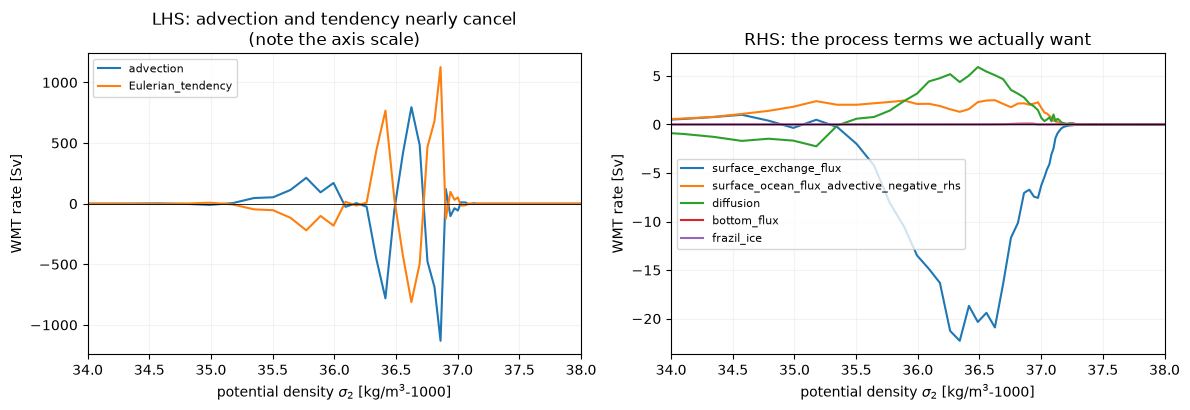

In [15]:
rhs_terms = ["surface_exchange_flux", "surface_ocean_flux_advective_negative_rhs",
             "diffusion", "bottom_flux", "frazil_ice"]
lhs_terms = ["advection", "Eulerian_tendency"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for v in lhs_terms:
    (G_na[v]*Sv).plot(ax=axes[0], label=v)
axes[0].set_title("LHS: advection and tendency nearly cancel\n(note the axis scale)")

for v in rhs_terms:
    if v in G_na:
        (G_na[v]*Sv).plot(ax=axes[1], label=v)
axes[1].set_title("RHS: the process terms we actually want")

for ax in axes:
    ax.set_xlim(34, 38)
    ax.set_xlabel(r"potential density $\sigma_{2}$ [kg/m$^{3}$-1000]")
    ax.set_ylabel("WMT rate [Sv]")
    ax.axhline(0, color="k", lw=0.6)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.15)
plt.tight_layout()

The right-hand panel already tells a story: a large **negative** surface-flux peak (recall the sign convention — negative means water is being made *denser* than the given threshold $\tilde{\lambda}$) somewhere near $\sigma_{2} \approx 36.3$, and a smaller, positive diffusion term. Let's put it in global context.

Throughout, we define surface-forced transformation as the sum of `surface_exchange_flux` (the direct air-sea fluxes of heat and salt) and `surface_ocean_flux_advective_negative_rhs` (the part arising because freshwater fluxes carry no salt, and so dilute or concentrate the water they enter). Together these are what is usually meant by "surface-forced transformation."

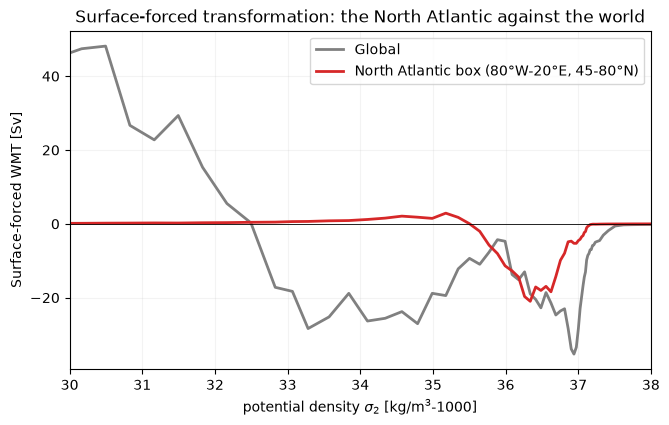

In [16]:
surface_forced_na = (G_na["surface_exchange_flux"]
                     + G_na["surface_ocean_flux_advective_negative_rhs"]) * Sv
surface_forced_global = (G_global["surface_exchange_flux"]
                         + G_global["surface_ocean_flux_advective_negative_rhs"]) * Sv

plt.figure(figsize=(7.5, 4.4))
surface_forced_global.plot(label="Global", color="0.5", lw=2)
surface_forced_na.plot(label="North Atlantic box (80°W-20°E, 45-80°N)", color="C3", lw=2)
plt.xlim(30, 38)
plt.axhline(0, color="k", lw=0.6)
plt.xlabel(r"potential density $\sigma_{2}$ [kg/m$^{3}$-1000]")
plt.ylabel("Surface-forced WMT [Sv]")
plt.title("Surface-forced transformation: the North Atlantic against the world")
plt.legend()
plt.grid(True, alpha=0.15)

In [17]:
dense = surface_forced_global.sigma2_l_target > 36.2
share = float(surface_forced_na.where(dense).sum()) / float(surface_forced_global.where(dense).sum())
cell_share = float(mask.sum()) / float((ds.wet > 0).sum())
print(f"For sigma2 > 36.2, the North Atlantic box accounts for {100*share:.0f}% of the "
      f"global surface-forced transformation,")
print(f"while occupying only {100*cell_share:.0f}% of the ocean's grid cells.")

For sigma2 > 36.2, the North Atlantic box accounts for 37% of the global surface-forced transformation,
while occupying only 8% of the ocean's grid cells.


The comparison earns its keep, in both directions. Over most of the density range the global curve is dominated by the tropics and the Southern Ocean, and the North Atlantic is a small correction — but at the dense end our box supplies **37%** of the world ocean's surface-forced transformation from just **8%** of its cells. That is a substantial concentration, and it is why this region is worth singling out.

It is also a useful check on our own enthusiasm: 37% is a long way from *all*. The remainder at these densities comes overwhelmingly from the Southern Ocean, around Antarctica, where the other great dense water mass of the world ocean is formed. The North Atlantic is one of two such places, not the only one.

## 4. Which surface flux does the work?

"Surface forcing" is not a physical process; it is a bucket. `xbudget.BudgetQuery(...).aggregate` takes a `decompose=` argument that opens the bucket up into the individual air-sea fluxes, and splits diffusion into its lateral and interfacial parts.

In [18]:
decomposed_budgets = xbudget.BudgetQuery(grid, budgets_dict).aggregate(
    decompose=["diffusion", "surface_exchange_flux", "nonadvective"]
)
wmt_dec = xwmt.WaterMassTransformations(grid, decomposed_budgets)
sorted(wmt_dec.available_processes())

['Eulerian_tendency',
 'advection',
 'bottom_flux',
 'diffusion_interfacial',
 'diffusion_lateral',
 'frazil_ice',
 'surface_exchange_flux_advective',
 'surface_exchange_flux_evaporation',
 'surface_exchange_flux_icebergs',
 'surface_exchange_flux_nonadvective_basal',
 'surface_exchange_flux_nonadvective_latent',
 'surface_exchange_flux_nonadvective_longwave',
 'surface_exchange_flux_nonadvective_sensible',
 'surface_exchange_flux_nonadvective_shortwave',
 'surface_exchange_flux_rain_and_ice',
 'surface_exchange_flux_rivers',
 'surface_exchange_flux_sea_ice_melt',
 'surface_exchange_flux_snow',
 'surface_exchange_flux_virtual_precip_restoring',
 'surface_ocean_flux_advective_negative_lhs',
 'surface_ocean_flux_advective_negative_rhs']

A caution on that list: `available_processes()` reports what the *budget dictionary* describes, which is not the same as what this *dataset* can deliver. Several of the advertised terms require diagnostics that are not in this file, and will simply be absent from the result rather than raising. It is worth checking what you actually got rather than treating the list as a promise.

In [19]:
with warnings.catch_warnings():
    warnings.simplefilter(action="ignore", category=FutureWarning)
    G_dec = wmt_dec.integrate_transformations(
        "sigma2", bins=sigma2_i, mask=mask, **kwargs
    ).mean("time")
with ProgressBar():
    G_dec.load()

advertised = sorted(wmt_dec.available_processes())
returned = [v for v in advertised if v in G_dec]
missing = [v for v in advertised if v not in G_dec]
print(f"Returned {len(returned)} of {len(advertised)} advertised processes.\n")
print("Absent from this dataset:")
for v in missing:
    print(f"  - {v}")

[                                        ] | 0% Completed | 71.17 us

[##                                      ] | 7% Completed | 108.09 ms

[##                                      ] | 7% Completed | 213.45 ms

[####                                    ] | 10% Completed | 320.27 ms

[#####                                   ] | 12% Completed | 430.96 ms

...

[#################################       ] | 83% Completed | 1.22 s

[#################################       ] | 83% Completed | 1.32 s

[###################################     ] | 88% Completed | 1.42 s

[########################################] | 100% Completed | 1.53 s

Returned 14 of 21 advertised processes.

Absent from this dataset:
  - surface_exchange_flux_evaporation
  - surface_exchange_flux_icebergs
  - surface_exchange_flux_rain_and_ice
  - surface_exchange_flux_rivers
  - surface_exchange_flux_sea_ice_melt
  - surface_exchange_flux_snow
  - surface_exchange_flux_virtual_precip_restoring


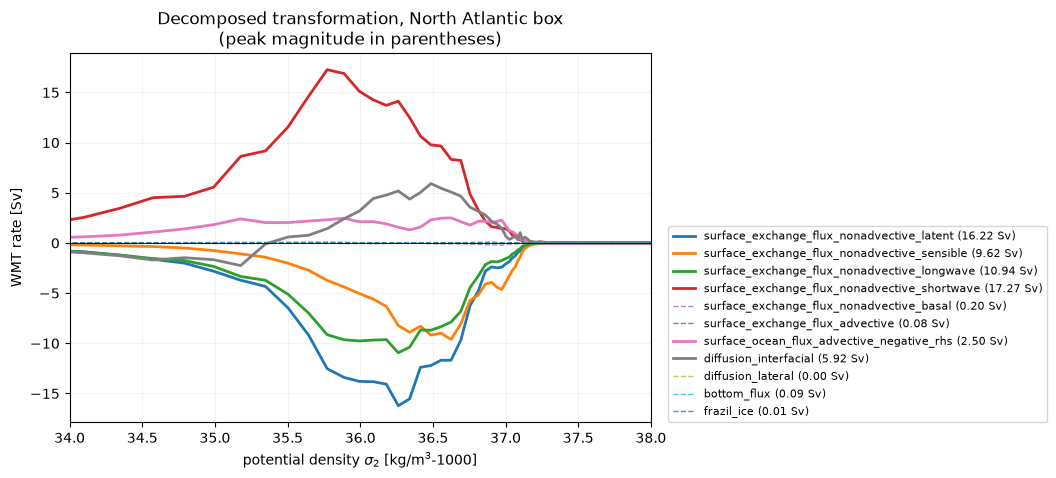

In [20]:
processes = [
    "surface_exchange_flux_nonadvective_latent",
    "surface_exchange_flux_nonadvective_sensible",
    "surface_exchange_flux_nonadvective_longwave",
    "surface_exchange_flux_nonadvective_shortwave",
    "surface_exchange_flux_nonadvective_basal",
    "surface_exchange_flux_advective",
    "surface_ocean_flux_advective_negative_rhs",
    "diffusion_interfacial",
    "diffusion_lateral",
    "bottom_flux",
    "frazil_ice",
]

plt.figure(figsize=(7.5, 4.8))
for v in processes:
    if v not in G_dec:
        continue
    amp = float(abs(G_dec[v]*Sv).max())
    style = dict(lw=2) if amp > 1 else dict(lw=1, ls="--", alpha=0.8)
    (G_dec[v]*Sv).plot(label=f"{v} ({amp:.2f} Sv)", **style)
plt.xlim(34, 38)
plt.axhline(0, color="k", lw=0.6)
plt.xlabel(r"potential density $\sigma_{2}$ [kg/m$^{3}$-1000]")
plt.ylabel("WMT rate [Sv]")
plt.title("Decomposed transformation, North Atlantic box\n(peak magnitude in parentheses)")
plt.legend(loc=(1.03, 0), fontsize=8)
plt.grid(True, alpha=0.15)

The decomposition is clean and physically sensible. Three cooling terms — **latent** (16.2 Sv), **longwave** (10.9 Sv) and **sensible** (9.6 Sv) heat loss — all densify, and all peak at essentially the same density. Against them, **shortwave** heating (17.3 Sv) lightens, offsetting about half of their 36.8 Sv sum. Annual-mean NADW formation is the residual of a near-cancellation between solar heating and turbulent-plus-radiative cooling, which is one more reason to treat the exact magnitude with care.

Two terms deserve a note. `diffusion_lateral` is **identically zero** here — the lateral diffusive tendency diagnostic is present in this coarsened dataset but every value in it is zero, so all of the diffusion in the previous figure is `diffusion_interfacial`, i.e. mixing across density surfaces. And `surface_exchange_flux_nonadvective_basal` (ice-shelf basal melt) is small but nonzero, as one would expect at these latitudes.

## 5. Finding the peak isopycnal — programmatically

Now the central question: **at which density does surface forcing form the most dense water?**

It is tempting to hardcode a value from a previous study, or from another notebook. Don't. `xarray`'s `idxmin`/`idxmax` return the coordinate value at which a `DataArray` attains its extremum, so we can simply ask the data. With the sign convention in force — negative transformation means mass is being moved *toward higher* density — the strongest densification is the **minimum** of the surface-forced curve.

In [21]:
sigma2_peak = float(surface_forced_na.idxmin())
G_peak = float(surface_forced_na.min())

sigma2_light = float(surface_forced_na.idxmax())
G_light = float(surface_forced_na.max())

print(f"Peak surface-forced DENSIFICATION: sigma2 = {sigma2_peak:.3f}, {G_peak:.2f} Sv")
print(f"Peak surface-forced LIGHTENING:    sigma2 = {sigma2_light:.3f}, {G_light:+.2f} Sv")

Peak surface-forced DENSIFICATION: sigma2 = 36.340, -20.98 Sv
Peak surface-forced LIGHTENING:    sigma2 = 35.177, +2.89 Sv


> $\sigma_{2} = 36.34$.

That number deserves a double-take, because NADW proper is conventionally taken to be *denser* than this — $\sigma_{2} \gtrsim 36.8$, with the deep overflow waters denser still. Surface forcing peaks a full 0.5 kg/m³ **lighter** than the water mass we set out to explain. So let us check what surface forcing is actually doing at NADW densities:

In [22]:
sigma2_overflow = float(ds.sigma2_l.sel(sigma2_l=36.9, method="nearest"))

for s in [sigma2_peak, 36.5, 36.7, sigma2_overflow, 37.1]:
    sf = float(surface_forced_na.sel(sigma2_l_target=s, method="nearest"))
    df = float((G_dec["diffusion_interfacial"]*Sv).sel(sigma2_l_target=s, method="nearest"))
    print(f"  sigma2 = {s:6.3f}:  surface-forced {sf:7.2f} Sv   |   interfacial diffusion {df:+6.2f} Sv")

frac = float(surface_forced_na.sel(sigma2_l_target=sigma2_overflow, method="nearest")) / G_peak
print(f"\nAt sigma2 = {sigma2_overflow:.3f}, surface forcing retains {100*frac:.0f}% "
      f"of its peak magnitude,")
print("while interfacial diffusion is still active.")

  sigma2 = 36.340:  surface-forced  -20.98 Sv   |   interfacial diffusion  +4.37 Sv
  sigma2 = 36.500:  surface-forced  -18.04 Sv   |   interfacial diffusion  +5.92 Sv
  sigma2 = 36.700:  surface-forced  -14.28 Sv   |   interfacial diffusion  +4.67 Sv
  sigma2 = 36.904:  surface-forced   -4.69 Sv   |   interfacial diffusion  +2.17 Sv
  sigma2 = 37.100:  surface-forced   -2.10 Sv   |   interfacial diffusion  +1.03 Sv

At sigma2 = 36.904, surface forcing retains 22% of its peak magnitude,
while interfacial diffusion is still active.


This is the notebook's payoff, and it is physics rather than a bug.

The reason is simple once stated: **surface fluxes can only transform water that is actually at the surface.** A surface heat flux acts on the density classes that outcrop, and in the annual mean the densest water outcropping over most of this box sits near $\sigma_{2} \approx 36.3$–36.4. Water denser than that is, almost everywhere, capped by lighter water and insulated from the atmosphere — so the atmosphere cannot make it.

But notice that the collapse is *partial*, not total: at $\sigma_{2} = 36.9$ surface forcing is still running at **22%** of its peak, some -4.7 Sv. That is much too large to dismiss, and it is a real clue rather than noise. Some water at NADW density evidently *is* outcropping somewhere in this box. The integral cannot tell us where — so let's go and look.

## 6. Mapping *where* it happens

`integrate_transformations` collapses the horizontal dimensions. Its sibling `map_transformations` does not: it returns the transformation in each grid column, so we can see the geography. It takes the same per-call `mask=`.

We compute the map once and select two isopycnals from it: the peak surface-forced density we just found, and an overflow density at $\sigma_{2} \approx 36.9$.

In [23]:
with warnings.catch_warnings():
    warnings.simplefilter(action="ignore", category=FutureWarning)
    G_map = wmt.map_transformations("sigma2", bins=sigma2_i, mask=mask).mean("time")
with ProgressBar():
    G_map.load()

surface_forced_map = (G_map["surface_exchange_flux"]
                      + G_map["surface_ocean_flux_advective_negative_rhs"]) * Sv
surface_forced_map

[                                        ] | 0% Completed | 54.08 us

[###########                             ] | 28% Completed | 107.01 ms

[###########                             ] | 28% Completed | 212.39 ms

[#############                           ] | 33% Completed | 319.83 ms

[###############                         ] | 37% Completed | 424.46 ms

...

[###############################         ] | 77% Completed | 1.07 s

[###############################         ] | 77% Completed | 1.17 s

[##################################      ] | 85% Completed | 1.28 s

[########################################] | 100% Completed | 1.39 s

<xarray.DataArray (yh: 180, xh: 240, sigma2_l_target: 74)> Size: 26MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], shape=(180, 240, 74))
Coordinates:
  * yh               (yh) int64 1kB 0 1 2 3 4 5 6 ... 174 175 176 177 178 179
  * xh               (xh) int64 2kB 0 1 2 3 4 5 6 ... 234 235 236 237 238 239
    areacello        (yh, xh) float64 346kB 1.25e+09 1.245e+09 ... 1.376e+08
    deptho           (yh, xh) float32 173kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    geolat           (yh, xh) float64 346kB -79.65 -79.64 -79.63 ... 65.03 64.39
    geolon           (yh, xh) float64 346kB -299.1 -297.6 -296.1 ... 59.94 59.98
    lat              (yh, xh) float64 346kB -79.65 -79.64 -79.63 ... 65.03 64.38
    lon              (yh, xh) float64 346kB -299.1 -297.6 -296.1 ... 59.94 59.98
    wet              (yh, xh) float32 173kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
  * sigma2_l_target  (sigma2_l_target) float64 592B 4.246 13.56 ... 37.9 38.49
Attributes:
    cell_measures:  volume: volcello area: areacello
    cell_methods:   area:mean sigma2_l:mean yh:mean xh:mean time:mean
    standard_name:  sea_water_potential_temperature
    time_avg_info:  average_T1,average_T2,average_DT
    xbudget_op:     product

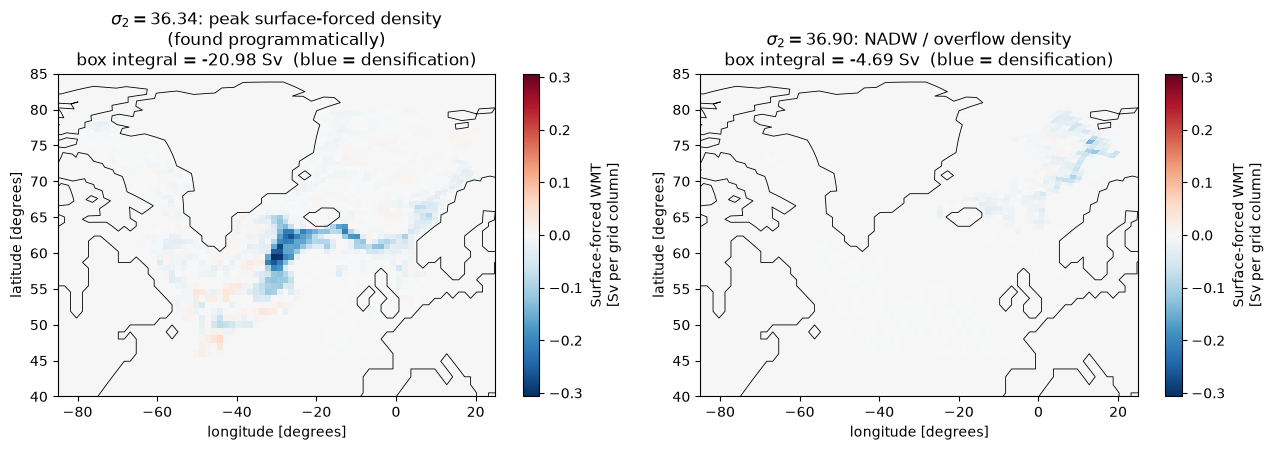

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
levels = [sigma2_peak, sigma2_overflow]
titles = ["peak surface-forced density\n(found programmatically)",
          "NADW / overflow density"]

# Both panels share a colour scale, set by the peak isopycnal: the comparison
# between them is the entire point, so they must not be normalised separately.
vmax = float(abs(surface_forced_map.sel(sigma2_l_target=sigma2_peak, method="nearest")).max())

for ax, lev, title in zip(axes, levels, titles):
    field = surface_forced_map.sel(sigma2_l_target=lev, method="nearest")
    pc = field.plot(x="geolon", y="geolat", ax=ax, cmap="RdBu_r",
                    vmin=-vmax, vmax=vmax,
                    cbar_kwargs={"label": "Surface-forced WMT\n[Sv per grid column]"})
    (ds.wet == 0).plot.contour(levels=[0], colors="k", x="geolon", y="geolat",
                               linewidths=0.6, ax=ax)
    ax.set_xlim(-85, 25)
    ax.set_ylim(40, 85)
    ax.set_xlabel("longitude [degrees]")
    ax.set_ylabel("latitude [degrees]")
    integrated = float(surface_forced_na.sel(sigma2_l_target=lev, method="nearest"))
    ax.set_title(rf"$\sigma_{{2}} = {lev:.2f}$: {title}" "\n"
                 rf"box integral = {integrated:.2f} Sv  (blue = densification)")
plt.tight_layout()

The two panels are drawn on the **same colour scale**, and that is the whole point.

On the left, at $\sigma_{2} = 36.34$, the region lights up — but not uniformly, and not quite where the textbook summary would lead you to expect. The densification is concentrated in a compact, intense patch in the **Irminger Sea and Iceland Basin**, south and east of Denmark Strait, peaking around 31°W, 59°N. The **Labrador Sea**, the site most famously associated with deep convection, is comparatively quiet in this annual mean, and part of the subpolar gyre to its southeast is actually *lightening* (red).

On the right, at NADW density proper, the map is not blank at all — the signal has **moved**. Essentially all of the remaining surface-forced densification has relocated into the **Nordic Seas**, north of the Greenland–Scotland Ridge. Let's confirm that impression with numbers rather than trusting our eyes on a colour scale:

In [25]:
# Nordic Seas: east of Greenland and north of the Greenland-Scotland Ridge.
nordic = (lon > -10) & (ds.geolat > 63) & mask
rest_of_box = mask & ~nordic

print(f"{'isopycnal':>12} {'box total':>11} {'Nordic Seas':>20} {'rest of box':>20}")
for lev, name in [(sigma2_peak, "peak"), (sigma2_overflow, "overflow")]:
    f = surface_forced_map.sel(sigma2_l_target=lev, method="nearest")
    tot, nor, rest = float(f.sum()), float(f.where(nordic).sum()), float(f.where(rest_of_box).sum())
    print(f"sigma2 = {lev:6.2f} {tot:8.2f} Sv {nor:12.2f} Sv ({100*nor/tot:3.0f}%) "
          f"{rest:12.2f} Sv ({100*rest/tot:3.0f}%)")

   isopycnal   box total          Nordic Seas          rest of box
sigma2 =  36.34   -20.98 Sv        -2.06 Sv ( 10%)       -18.92 Sv ( 90%)
sigma2 =  36.90    -4.69 Sv        -4.21 Sv ( 90%)        -0.48 Sv ( 10%)


The migration is emphatic: at $\sigma_{2} = 36.34$ **90%** of the densification happens *outside* the Nordic Seas, in the open subpolar gyre; at $\sigma_{2} = 36.9$ **90%** of it happens *inside* them. The site of surface-forced formation is not fixed — it tracks poleward with density, because that is where progressively denser water manages to reach the surface.

This also retroactively justifies the box we drew in Section 1. Had we stopped the eastern boundary short of the Nordic Seas, as a "North Atlantic" box naturally might, we would have discarded the 90% of NADW-density formation that happens there and concluded that surface forcing makes almost none at all. The region you choose determines the answer you get.

So, to answer the question we started with.

> In this model, the subpolar North Atlantic's surface fluxes densify water at a peak annual-mean rate of about 21 Sv, but they do it at $\sigma_{2} \approx 36.3$ — lighter than NADW — and mostly in the Irminger Sea and Iceland Basin. The only place the surface directly makes water at NADW density is the Nordic Seas, and only at about a fifth of the peak rate.

Both of those strands have to be reconciled with the fact that the deep Atlantic is full of $\sigma_{2} \gtrsim 36.8$ water. The Nordic Seas contribution cannot get there without crossing the Greenland–Scotland Ridge, which it does as the Denmark Strait and Faroe Bank Channel **overflows** — entraining ambient water as they plunge, and being modified on the way. And the much larger 36.3 peak has to be densified in the **interior** by the mixing we saw remains active at all these densities. Neither pathway leaves a surface signature, and neither is something `xwmt` can quantify on its own.

## 7. Appendix: what `rebin=True` does, and why not to use it here

Section 2 explained that `xwmt` takes its prebinned path because $\sigma_{2}$ is already the model's vertical coordinate. The `WaterMassTransformations` constructor offers `rebin=True` to **override** that: it forces a transformation into the target coordinate even when that coordinate already exists, by recomputing density from the model's temperature and salinity through the equation of state.

Note that `rebin` is a *constructor* argument, not a per-call one — unlike `mask`, you cannot vary it between calls on the same object.

It is undocumented elsewhere, so let's find out what it actually does. Same region, same native bins; only `rebin` differs.

In [26]:
wmt_rebin = xwmt.WaterMassTransformations(grid, simple_budgets, rebin=True)

with warnings.catch_warnings():
    warnings.simplefilter(action="ignore", category=FutureWarning)
    G_rebin = wmt_rebin.integrate_transformations(
        "sigma2", bins=sigma2_i, mask=mask, **kwargs
    ).mean("time")
with ProgressBar():
    G_rebin.load()

surface_forced_rebin = (G_rebin["surface_exchange_flux"]
                        + G_rebin["surface_ocean_flux_advective_negative_rhs"]) * Sv

print(f"prebinned (default) : peak {float(surface_forced_na.min()):7.2f} Sv "
      f"at sigma2 = {float(surface_forced_na.idxmin()):.3f}")
print(f"rebin=True          : peak {float(surface_forced_rebin.min()):7.2f} Sv "
      f"at sigma2 = {float(surface_forced_rebin.idxmin()):.3f}")

[                                        ] | 0% Completed | 60.21 us

[#####                                   ] | 14% Completed | 107.00 ms

[#####                                   ] | 14% Completed | 212.30 ms

[#######                                 ] | 18% Completed | 314.94 ms

[#######                                 ] | 18% Completed | 418.55 ms

[#######                                 ] | 18% Completed | 533.47 ms

[#########################               ] | 64% Completed | 661.30 ms

[########################################] | 100% Completed | 768.53 ms

prebinned (default) : peak  -20.98 Sv at sigma2 = 36.340
rebin=True          : peak  -13.27 Sv at sigma2 = 36.625


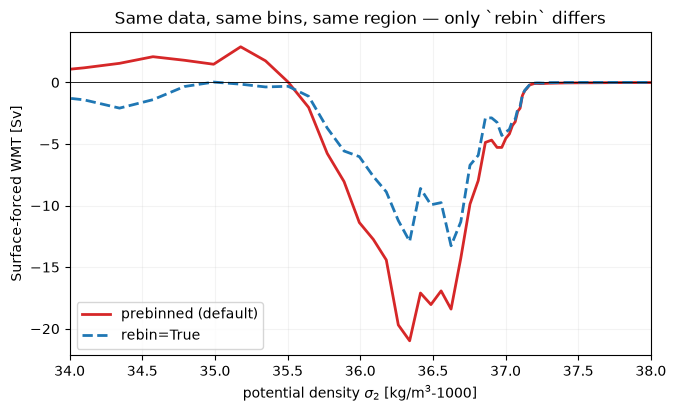

In [27]:
plt.figure(figsize=(7.5, 4.2))
surface_forced_na.plot(label="prebinned (default)", color="C3", lw=2)
surface_forced_rebin.plot(label="rebin=True", color="C0", lw=2, ls="--")
plt.xlim(34, 38)
plt.axhline(0, color="k", lw=0.6)
plt.xlabel(r"potential density $\sigma_{2}$ [kg/m$^{3}$-1000]")
plt.ylabel("Surface-forced WMT [Sv]")
plt.title("Same data, same bins, same region — only `rebin` differs")
plt.legend()
plt.grid(True, alpha=0.15)

`rebin=True` runs without complaint and behaves as documented — it does force the transformation rather than reusing the existing coordinate — but it gives a **materially different answer**: a peak roughly a third weaker, displaced to a denser isopycnal. Both curves cannot be right, and for this dataset the default is the one to trust.

The reason is instructive. On the prebinned path, `xwmt` uses `sigma2_l`, which is the *exact* density defining each layer: this is an isopycnal-coordinate model, and a layer's density is a property of the coordinate, known perfectly. With `rebin=True`, `xwmt` instead recomputes density from each layer's mean temperature and salinity via the equation of state. Because the equation of state is nonlinear, the density of the mean $T$ and $S$ is not the mean of the density, and in the subpolar North Atlantic — where a single layer spans a wide range of $T$–$S$ properties along an isopycnal — that discrepancy is not small. The recomputed density is a lossy reconstruction of a quantity the file already stores exactly.

**Rule of thumb:** if your model's vertical coordinate already *is* your target $\lambda$, let `xwmt` use it. `rebin=True` exists for the cases where you genuinely need a target coordinate that the grid does not already provide, and it costs accuracy when you don't.

## Summary and next steps

Retracing the argument:

1. On a tripolar grid, geography lives in the 2D `geolon`/`geolat` variables, not in the `xh`/`yh` dimensions — and `geolon`'s convention here is -300..60, so **normalize, and check the range** rather than assuming.
2. `wet` is **fractional**; select cells with `wet > 0`, not `wet == 1`.
3. Bin on the model's **native interfaces** when the vertical coordinate is already your $\lambda$. `xwmt` takes its **prebinned** path there and uses `xgcm` regardless of `method=`; `rebin=True` overrides that and, on this dataset, degrades the answer.
4. A single `WaterMassTransformations` object serves both global and regional questions through the per-call `mask=` keyword.
5. Surface-forced transformation in the subpolar North Atlantic peaks at $\sigma_{2} = 36.34$, with about **21 Sv** of densification — driven by latent, longwave and sensible cooling against opposing shortwave heating — which is **lighter than NADW proper**. That peak sits mostly in the Irminger Sea and Iceland Basin; the Labrador Sea is comparatively quiet in this annual mean.
6. The formation site **migrates with density**. At the peak isopycnal, 90% of the densification is outside the Nordic Seas; at NADW density, 90% of it is inside them — because the Nordic Seas are the only place dense enough water reaches the surface.

Those last two results are where this notebook stops and the physics keeps going. The surface makes a lot of water at $\sigma_{2} \approx 36.3$ and only a little at 36.9, yet the deep Atlantic is full of water denser than 36.8. Closing that gap requires two things we deliberately did not compute: **interior mixing**, which works on the light peak from below, and the **lateral transport** of the Nordic Seas contribution across our box's perimeter and over the Greenland–Scotland Ridge, entraining as it goes.

Both lie outside what `xwmt` alone can tell you, and both are exactly what its companion package [xwmb](https://github.com/hdrake/xwmb) is built for: `xwmb` assembles complete water mass *budgets* for a region, including the transport terms across its boundary, on top of the transformations that `xwmt` provides. It is the natural next step for anyone who wants to close the budget that this notebook deliberately left open.